In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [12]:
import pysam

In [54]:
vcf_in = pysam.VariantFile("hprc_multisample.INS_comp.vcf")

In [55]:
records = []
for record in vcf_in:
    records.append([record.chrom, record.pos, record.alts[0], float(record.info['SVCOMP'][0])])

In [58]:
comp = pd.DataFrame(records,columns=['chrom','pos','alt','comp'])

In [81]:
sorted = comp.sort_values(by='comp', ascending=False, ignore_index=True)

<Axes: xlabel='comp', ylabel='Count'>

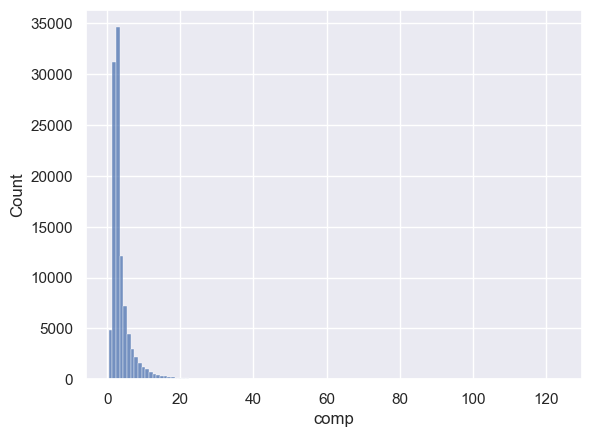

In [68]:
sns.set_theme()
sns.histplot(comp, x="comp", binwidth=1)

(0.0, 100.0)

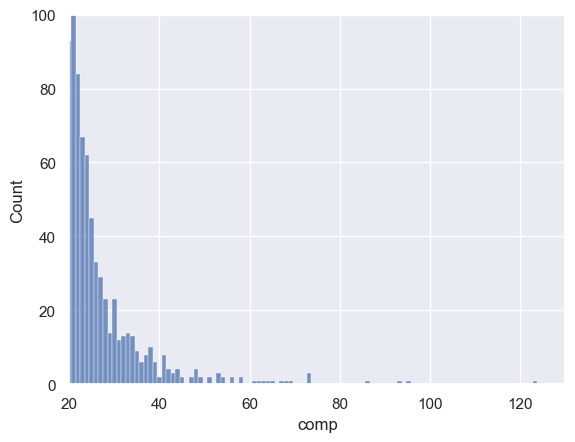

In [77]:
sns.histplot(comp, x="comp", binwidth=1)
plt.xlim(20,)
plt.ylim(0,100)

In [93]:
# print percentiles
percentiles = np.arange(0.0, 1.1, 0.1)
row_indices = (percentiles * (len(sorted) - 1)).astype(int)
percentile_rows = sorted.iloc[row_indices]

In [94]:
percentile_rows

,chrom,pos,alt,comp
0,chr16,66490464,AAAATAAAATAAAATAAAATGGAATGGAATGGAATGGAATGGAATG...,123.854167
10684,chr2,117643459,ATAATATTTATATATATAAATATTATATATACTATTTATATATATA...,6.949153
21368,chr19,2348700,TTCTCTCTCTCCACACACACTCACGCGCTCTCATTCGCTTGATTCC...,4.723404
32052,chr1,123415590,TGCTAGACAGAAGAATTCTCAGTAACTTCCTTGTGTTGTGTGTTTT...,3.666667
42737,chr17,23053453,CTCTGAGGATTTCGTTGGAAACGGGATAAAACGCATAGAACTAAAA...,3.120370
53421,chr4,49286104,AGGCTGGGGTGGTTGACATGAGAGAGACCGGGGAGTAACTGAGTGA...,2.694444
64105,chr1,185651639,ATTTTTTTTTTCTTTTTTTTTTTTTTTTTTTTTGAGACGGAGTCTC...,2.512000
74790,chr7,59139927,CTTCGTTGGAAACGGGATTTTTCATATAATGCTAGACGGAAGAATT...,2.257426
85474,chr5,1422450,ACCCACAGTGCTGCCCACGCTGCTGGGTGCCCACCGCTGCCCACGG...,1.951220
96158,chrX,71708929,TCAGGAGTTCCAGACGAGCCTGGGCAAGACGGTGAAACCCTGTCTC...,1.589286
